In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from nnsight import LanguageModel

model = LanguageModel("Qwen/Qwen3-32B")

tokenizer = model.tokenizer

In [3]:
PROMPT_TEMPLATE = """A ball rolls by. Q: What is the second word in the previous sentence? A: ball
Pizza is the best. Q: What is the first word in the previous sentence? A: Pizza
{}. Q: What is the {} word in the previous sentence? A:"""
OPTIONS = ["first", "second", "third"]

In [12]:
article_first = [
    ['An artist Jane paints', 'The artist Jane paints'],
    ['The pet fish swims', 'A pet fish swims'],
    ['An animal fish swims', 'The animal fish swims'],
    ['A friend Tom visits', 'The friend Tom visits'],
    ['The woman Mary cooks', 'A woman Mary cooks'],
    ['A machine needs fuel', 'The machine needs fuel'],
    ['A toy is fun', 'The toy is fun'],
    ['A plant loves sun', 'The plant loves sun'],
    ['The dog is loud', 'A dog is loud'],
    ['A breeze blows softly', 'The breeze blows softly'],
    ['The mouse runs away', 'A mouse runs away'],
    ['A child plays happily', 'The child plays happily'],
    ['A clock ticks slowly', 'The clock ticks slowly'],
    ['A book smells fresh', 'The book smells fresh'],
    ['The library is peaceful', 'A library is peaceful'],
    ['A street sounds noisy', 'The street sounds noisy'],
    ['The train arrives soon', 'A train arrives soon'],
    ['A knife cuts easily', 'The knife cuts easily'],
    ['A flower smells sweet', 'The flower smells sweet'],
    ['A wire bends easily', 'The wire bends easily'],
]

article_second = [
    ['Jack the boy runs', 'Jack a boy runs'],
    ['Jack a student learns', 'Jack the student learns'],
    ['Jack an actor plays', 'Jack the actor plays'],
    ['Jane the girl sings', 'Jane a girl sings'],
    ['Eat the pizza now', 'Eat a pizza now'],
    ['Jane an artist paints', 'Jane the artist paints'],
    ['Fish the pet swim', 'Fish a pet swims'],
    ['What the day brings', 'What a day brings'],
    ['Fish an animal swims', 'Fish the animal swims'],
    ['Tom the man works', 'Tom a man works'],
    ['Tom a friend visits', 'Tom the friend visits'],
    ['Tom an employee arrives', 'Tom the employee arrives'],
    ['Kate the woman cooks', 'Kate a woman cooks'],
    ['Kate a nurse cares', 'Kate the nurse cares'],
    ['Kate an author writes', 'Kate the author writes'],
    ['Cars the fast vehicle', 'Cars a fast vehicle'],
    ['Bob a scientist studies', 'Bob the scientist studies'],
    ['Cause a societal shift', 'Cause the societal shift'],
    ['See the root grow', 'See a root grow'],
    ['Trees a big plant', 'Trees the big plant']
]

article_third = [
    ['Jack is a boy', 'Jack is the boy'],
    ['Jane is the girl', 'Jane is a girl'],
    ['Fish are the pet', 'Fish are a pet'],
    ['Fish need a bowl', 'Fish need the bowl'],
    ['Tom is the man', 'Tom is a man'],
    ['Jim is a guy', 'Jim is the guy'],
    ['Bob is an friend', 'Bob is the friend'],
    ['Mary is the lady', 'Mary is a lady'],
    ['Jane is a woman', 'Jane is the woman'],
    ['Cars are the machine', 'Cars are a machine'],
    ['I want a flower', 'I want the flower'],
    ['Weapons are the menace', 'Weapons are a menace'],
    ['I had an idea', 'I had the idea'],
    ['I love a forest', 'I love the forest'],
    ['I love the girl', 'I love a girl'],
    ['Kids play a game', 'Kids play the game'],
    ['He wants the drink', 'He wants a drink'],
    ['She says the word', 'She says a word'],
    ['I know a way', 'I know the way'],
    ['Movie of the era', 'Movie of an era']
 ]

In [13]:
article_first_clean = []
for sentence_pair in article_first[:20]:
    clean_sentence_pair = []
    for sentence in sentence_pair:
        sentence_tokenized = tokenizer.encode(sentence)
        if len(sentence_tokenized) != 4:
            for token in sentence_tokenized:
                print(tokenizer.decode(token))
        else:
            clean_sentence_pair.append(sentence)
    article_first_clean.append(clean_sentence_pair)
assert article_first_clean == article_first[:20]

In [14]:
import torch
import time

correct_count = 0
total_count = 0

OPTION_INDEX = 0  # Change this index to select different word positions (0 for first, 1 for second, etc.)

valid_sentences = []

for sentence_pair in article_first[6:7]:
    valid_sentence_pair = []
    for sentence in sentence_pair:
        # Get the model's prediction for the next token
        prompt = PROMPT_TEMPLATE.format(sentence, OPTIONS[OPTION_INDEX])
        input_ids = model.tokenizer.encode(prompt)
        with model.trace(prompt, do_sample=False):
            logits = model.output.logits.save()
        predicted_token_id = logits[0, -1].argmax().item()
        predicted_token = model.tokenizer.decode([predicted_token_id])
        print(f"Prompt: {prompt}")
        print(f"Predicted token: {predicted_token}")
        print(f"Correct answer: {sentence.split()[OPTION_INDEX]}")
        print("-----")
        if predicted_token.strip().lower() == sentence.split()[OPTION_INDEX].lower():
            correct_count += 1
            # Add to valid sentences if correct
            valid_sentence_pair.append(sentence)
        total_count += 1
    valid_sentences.append(valid_sentence_pair)

Prompt: A ball rolls by. Q: What is the second word in the previous sentence? A: ball
Pizza is the best. Q: What is the first word in the previous sentence? A: Pizza
A toy is fun. Q: What is the first word in the previous sentence? A:
Predicted token:  A
Correct answer: A
-----
Prompt: A ball rolls by. Q: What is the second word in the previous sentence? A: ball
Pizza is the best. Q: What is the first word in the previous sentence? A: Pizza
The toy is fun. Q: What is the first word in the previous sentence? A:
Predicted token:  The
Correct answer: The
-----


In [8]:
valid_sentences

[['An artist Jane paints', 'The artist Jane paints'],
 ['The pet fish swims', 'A pet fish swims'],
 ['An animal fish swims', 'The animal fish swims'],
 ['A friend Tom visits', 'The friend Tom visits'],
 ['The woman Mary cooks', 'A woman Mary cooks'],
 ['A machine needs fuel', 'The machine needs fuel'],
 ['The invention changed society'],
 ['A plant loves sun', 'The plant loves sun'],
 ['The dog is loud', 'A dog is loud'],
 ['A breeze blows softly', 'The breeze blows softly'],
 ['The mouse runs away', 'A mouse runs away'],
 ['A child plays happily', 'The child plays happily'],
 ['A clock ticks slowly', 'The clock ticks slowly'],
 ['A book smells fresh', 'The book smells fresh'],
 ['The library is peaceful', 'A library is peaceful'],
 ['A street sounds noisy', 'The street sounds noisy'],
 ['The train arrives soon', 'A train arrives soon'],
 ['A knife cuts easily', 'The knife cuts easily'],
 ['A flower smells sweet', 'The flower smells sweet'],
 ['A wire bends easily', 'The wire bends eas

In [9]:
correct_count / total_count

0.975

In [95]:
accuracy_dict = {
    "first": 1.0,
    "second": 1.0,
    "third": 1.0,
}

<BarContainer object of 3 artists>

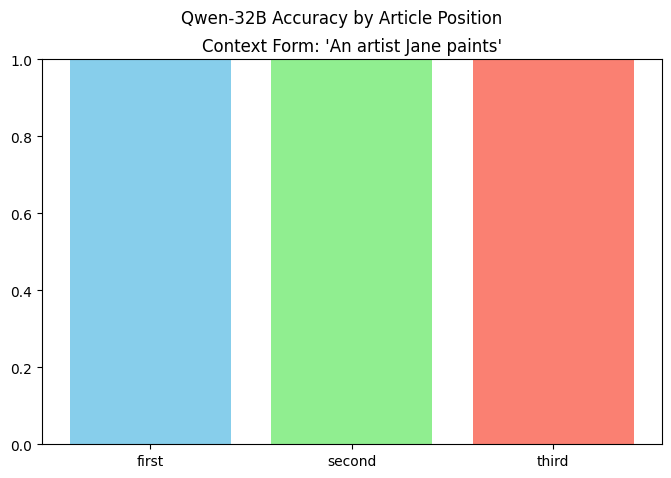

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.suptitle('Qwen-32B Accuracy by Article Position')
plt.title("Context Form: 'An artist Jane paints'")
plt.ylim(0, 1)
plt.bar(
    accuracy_dict.keys(),
    accuracy_dict.values(),
    color=["skyblue", "lightgreen", "salmon", "orange"],
)